In [44]:
# Setup: environment, imports, and random seed
import sys
print("Python version:", sys.version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from keras.datasets import fashion_mnist
from sklearn.metrics import accuracy_score, pairwise_distances
from scipy import stats

np.random.seed(42)

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [45]:
# Load Fashion-MNIST dataset using Keras
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Merge train and test sets
X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

# Flatten 28x28 images and scale pixel values to [0,1]
X = X.reshape(X.shape[0], -1).astype('float32')/255.0

print("Total images:", X.shape[0])
print("Image dimensions:", X.shape[1])
print("Classes:", np.unique(y))
print("Samples per class:", np.bincount(y))

Total images: 70000
Image dimensions: 784
Classes: [0 1 2 3 4 5 6 7 8 9]
Samples per class: [7000 7000 7000 7000 7000 7000 7000 7000 7000 7000]


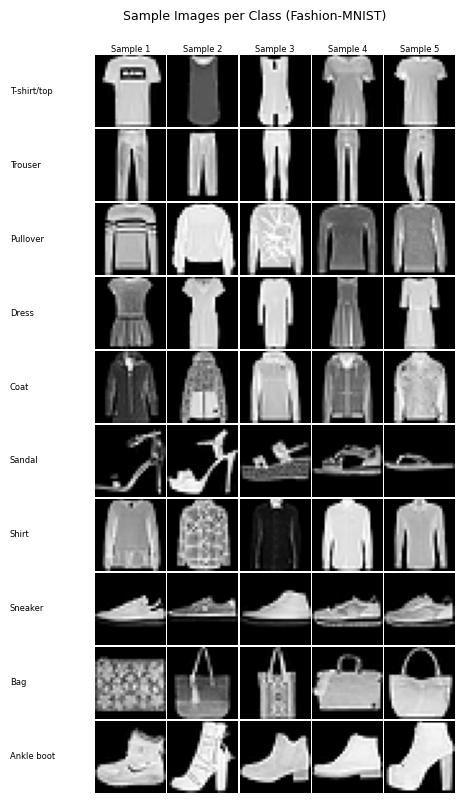

In [46]:
# Fashion-MNIST class names (sourced from Zalando's GitHub)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
n_samples = 5
fig, axes = plt.subplots(10, n_samples, figsize=(5,9))

for c in range(10):
    indices = np.where(y==c)[0][:n_samples]
    for j, idx in enumerate(indices):
        axes[c,j].imshow(X[idx].reshape(28,28), cmap='gray', aspect='auto')
        axes[c,j].axis('off')
        if c==0:
            axes[c,j].set_title(f'Sample {j+1}', fontsize=6, pad=2)

plt.suptitle('Sample Images per Class (Fashion-MNIST)', fontsize=9, y=0.98)
plt.subplots_adjust(left=0.18, top=0.93, hspace=0.02, wspace=0.02)
fig.canvas.draw()

for c in range(10):
    pos = axes[c, 0].get_position()
    fig.text(0.01, pos.y0 + pos.height/2, class_names[c], va='center', ha='left', fontsize=6)

plt.show()

In [47]:
# KNN computation
def run_knn(X, y, sampling_function, distance_metric, batch_size):
  k_values = [1,2,5,10,15,20]
  results = []

  # loop over different training sizes
  for N in range(1000, 6001, 500):
    print(f"Processing training size N={N}")

    # stratified train/test split using the given sampling function
    X_train_subset, y_train_subset, X_test_subset, y_test_subset = sampling_function(X, y, N)

    # stores one prediction per test example for each k
    all_predictions = {k: [] for k in k_values}
    n_test = X_test_subset.shape[0]

    # process test points in batches to save memory
    for b in range(int(np.ceil(n_test/batch_size))):
      start = b * batch_size
      end = min((b+1) * batch_size, n_test)
      X_batch = X_test_subset[start:end]

      # distance matrix between this batch of test points and all training points
      distances = pairwise_distances(
          X_batch,
          X_train_subset,
          metric=distance_metric,
          n_jobs=-1
      ).astype(np.float32)

      for k in k_values:

        # find indices of the k nearest training points for each test point
        nearest_indices = np.argpartition(distances, k-1, axis=1)[:,:k]
        nearest_labels = y_train_subset[nearest_indices]

        # majority vote label for each test point
        predictions = stats.mode(nearest_labels, axis=1, keepdims=False).mode
        all_predictions[k].extend(predictions)

    # compute global and per-class (local) accuracy for each k and this N
    for k in k_values:
      predictions = np.array(all_predictions[k])
      global_accuracy = np.mean(predictions == y_test_subset)
      local_accuracy = [
          accuracy_score(
              y_test_subset[y_test_subset == c],
              predictions[y_test_subset == c]
          )
          for c in range(10)
      ]
      results.append({
          'N': N,
          'k': k,
          'global_accuracy': global_accuracy,
          'local_accuracy': local_accuracy
      })

  return results

In [48]:
# Helper to summarize and visualize KNN results
def analyze_knn_results(df):

  # Global accuracy table (N x k)
  pivot = df.pivot(index='N', columns='k', values='global_accuracy')
  print("Global Accuracy Table:\n")
  print(pivot.round(4))

  # Best k for each N (by global accuracy)
  print("\nBest k per N:\n")
  best_k = df.loc[df.groupby('N')['global_accuracy'].idxmax(), ['N', 'k', 'global_accuracy']]
  print(best_k)

  print("\n")

  # Global accuracy vs N for each k
  plt.figure(figsize=(10,6))
  for k in sorted(df['k'].unique()):
    subset = df[df['k'] == k]
    plt.plot(subset['N'], subset['global_accuracy'], marker='o', label=f'k={k}')
  plt.title("Global Accuracy vs Training Size")
  plt.xlabel("Training size per class (N)")
  plt.ylabel("Global Accuracy")
  plt.legend()
  plt.grid(True)
  plt.show()

  print("\n")

  # Local per-class accuracy vs N for each k
  fig, axes = plt.subplots(2, 5, figsize=(20,8))
  axes = axes.flatten()
  classes = [f"{name} (Class {i})" for i, name in enumerate(class_names)]

  for c, (ax, name) in enumerate(zip(axes, classes)):
    for k in sorted(df['k'].unique()):
      subset = df[df['k'] == k]
      local_accs = [row[c] for row in subset['local_accuracy']]
      ax.plot(subset['N'], local_accs, marker='o', label=f'k={k}')
    ax.set_title(name)
    ax.set_xlabel("N")
    ax.set_ylabel("Local Accuracy")
    ax.grid(True)
    ax.legend(fontsize=6)

  plt.suptitle("Local Accuracy vs N per Class")
  plt.tight_layout()
  plt.show()

**Question 1:** KNN Performance Analysis on Fashion-MNIST with Varying Training Set Size (N) and k Values

In [49]:
# Random sampling: stratified random train/test split
def sample_per_class_random(X, y, N):
  train_indices = []
  test_indices = []

  # iterate over each class label present in y
  for c in np.unique(y):
    # all indices for class c
    class_indices = np.where(y==c)[0]
    # randomize within the class
    np.random.shuffle(class_indices)
    # first N for this class go to the training set
    train_indices.extend(class_indices[:N])
    # remaining 7000-N for this class go to the test set
    test_indices.extend(class_indices[N:])

  # build stratified train and test sets
  return X[train_indices], y[train_indices], X[test_indices], y[test_indices]

In [50]:
# KNN with random per-class sampling
results_q1 = run_knn(X, y, sample_per_class_random, 'euclidean', 3000)
df_q1 = pd.DataFrame(results_q1)
df_q1.to_csv("q1_results.csv", index=False)
print("\nResults saved to q1_results.csv\n")
print(df_q1)

Processing training size N=1000
Processing training size N=1500
Processing training size N=2000
Processing training size N=2500
Processing training size N=3000
Processing training size N=3500
Processing training size N=4000
Processing training size N=4500
Processing training size N=5000
Processing training size N=5500
Processing training size N=6000

Results saved to q1_results.csv

       N   k  global_accuracy  \
0   1000   1         0.812000   
1   1000   2         0.813350   
2   1000   5         0.825550   
3   1000  10         0.824417   
4   1000  15         0.818883   
..   ...  ..              ...   
61  6000   2         0.860700   
62  6000   5         0.868000   
63  6000  10         0.863200   
64  6000  15         0.856800   
65  6000  20         0.853300   

                                       local_accuracy  
0   [0.7723333333333333, 0.9625, 0.719833333333333...  
1   [0.8783333333333333, 0.9646666666666667, 0.826...  
2   [0.8263333333333334, 0.9523333333333334, 0.76

Global Accuracy Table:

k         1       2       5       10      15      20
N                                                   
1000  0.8120  0.8134  0.8256  0.8244  0.8189  0.8150
1500  0.8206  0.8226  0.8311  0.8287  0.8239  0.8210
2000  0.8280  0.8275  0.8371  0.8339  0.8279  0.8248
2500  0.8338  0.8333  0.8419  0.8394  0.8349  0.8322
3000  0.8373  0.8363  0.8459  0.8437  0.8392  0.8358
3500  0.8408  0.8409  0.8459  0.8443  0.8389  0.8361
4000  0.8480  0.8438  0.8512  0.8476  0.8434  0.8403
4500  0.8444  0.8445  0.8538  0.8520  0.8462  0.8441
5000  0.8490  0.8474  0.8568  0.8568  0.8506  0.8481
5500  0.8473  0.8463  0.8527  0.8501  0.8451  0.8421
6000  0.8610  0.8607  0.8680  0.8632  0.8568  0.8533

Best k per N:

       N  k  global_accuracy
2   1000  5         0.825550
8   1500  5         0.831073
14  2000  5         0.837120
20  2500  5         0.841911
26  3000  5         0.845900
32  3500  5         0.845886
38  4000  5         0.851200
44  4500  5         0.853800
50  5000  

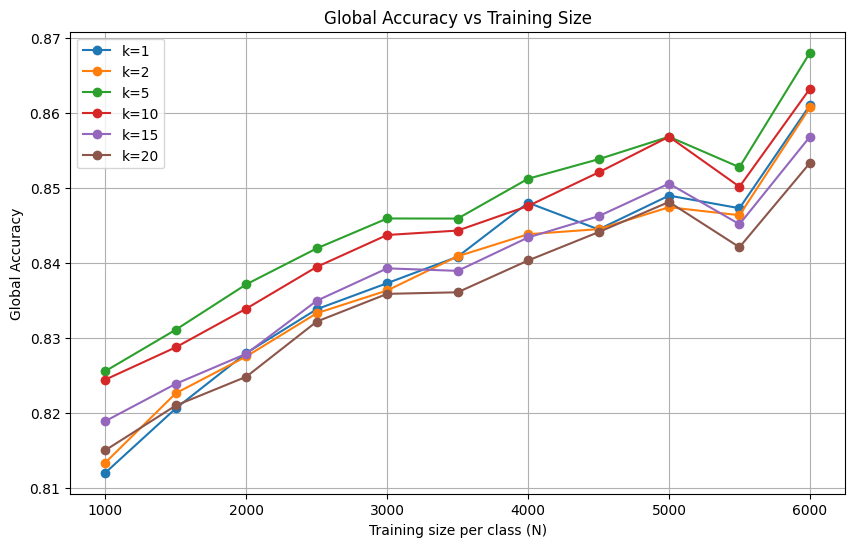

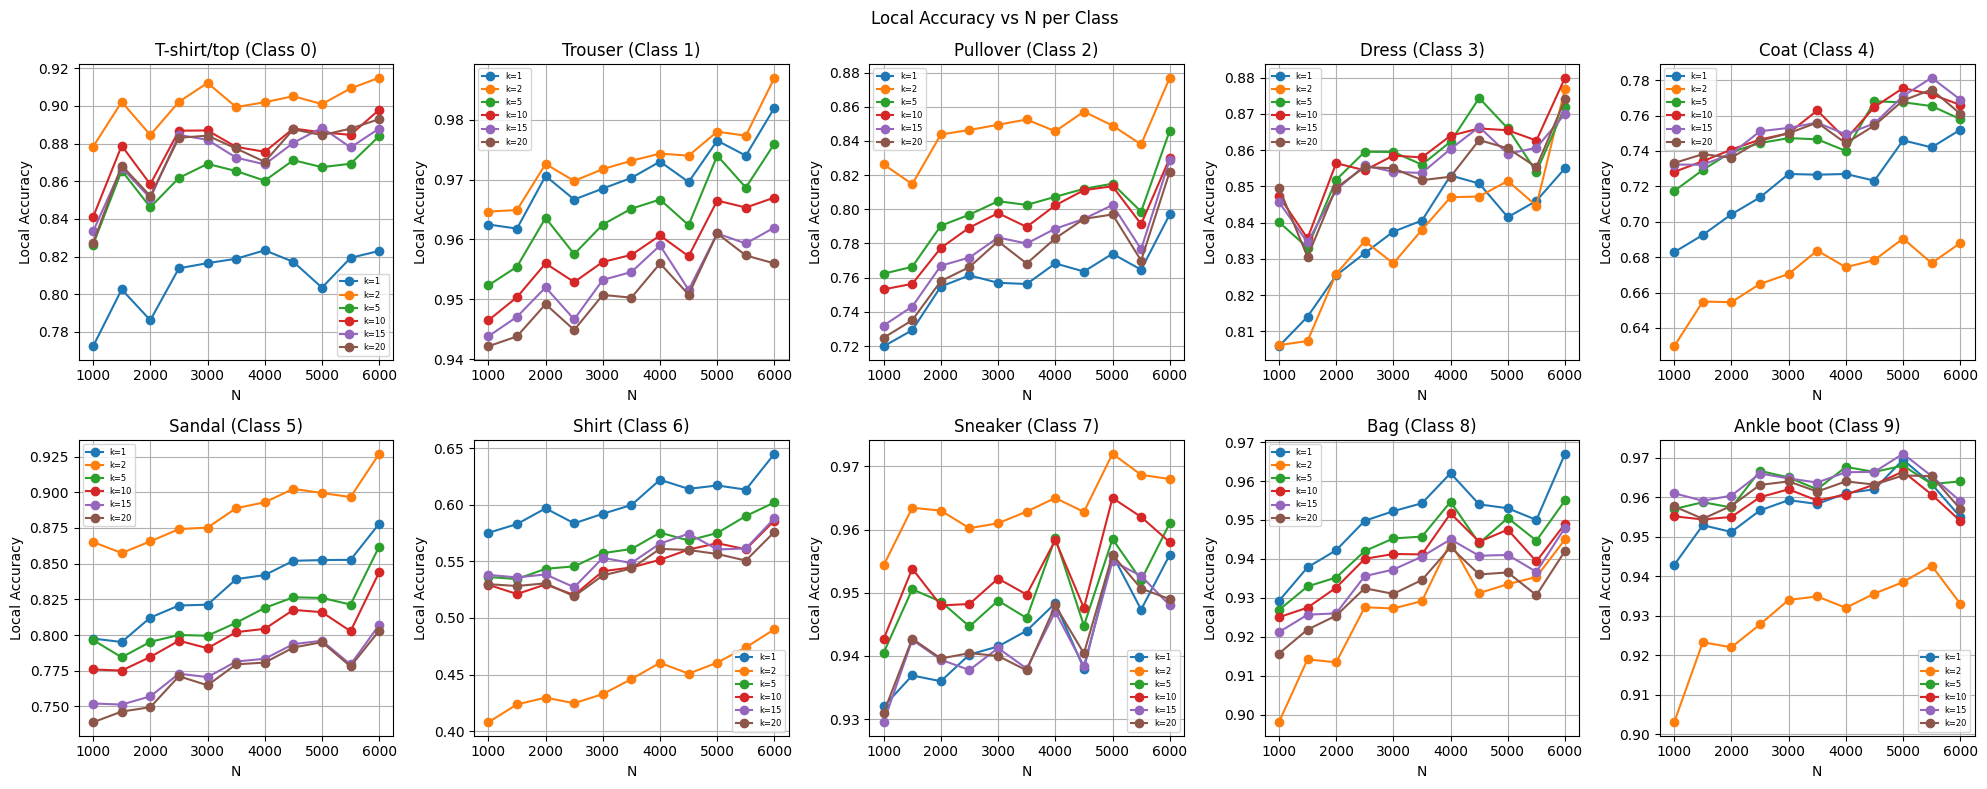

In [51]:
analyze_knn_results(df_q1)

**Question 2:** Evaluating the Effect of Training Data Indexing on KNN Performance

In [52]:
# Sequential sampling: stratified train/test split using original index order
def sample_per_class_sequential(X, y, N):
  train_indices = []
  test_indices = []

  # iterate over each class label present in y
  for c in np.unique(y):
    # all indices for class c
    class_indices = np.where(y == c)[0]
    # first N for this class go to the training set
    train_indices.extend(class_indices[:N])
    # remaining 7000-N for this class go to the test set
    test_indices.extend(class_indices[N:])

  # build stratified train and test sets
  return X[train_indices], y[train_indices], X[test_indices], y[test_indices]

In [53]:
# KNN with sequential per-class sampling
results_q2 = run_knn(X, y, sample_per_class_sequential, 'euclidean', 3000)
df_q2 = pd.DataFrame(results_q2)
df_q2.to_csv("q2_results.csv", index=False)
print("\nResults saved to q2_results.csv\n")
print(df_q2)

Processing training size N=1000
Processing training size N=1500
Processing training size N=2000
Processing training size N=2500
Processing training size N=3000
Processing training size N=3500
Processing training size N=4000
Processing training size N=4500
Processing training size N=5000
Processing training size N=5500
Processing training size N=6000

Results saved to q2_results.csv

       N   k  global_accuracy  \
0   1000   1         0.814917   
1   1000   2         0.813667   
2   1000   5         0.823167   
3   1000  10         0.821317   
4   1000  15         0.816217   
..   ...  ..              ...   
61  6000   2         0.846000   
62  6000   5         0.855400   
63  6000  10         0.851500   
64  6000  15         0.846200   
65  6000  20         0.841500   

                                       local_accuracy  
0   [0.7893333333333333, 0.9611666666666666, 0.729...  
1   [0.8885, 0.9633333333333334, 0.826, 0.80433333...  
2   [0.853, 0.9535, 0.7596666666666667, 0.8316666

Global Accuracy Table:

k         1       2       5       10      15      20
N                                                   
1000  0.8149  0.8137  0.8232  0.8213  0.8162  0.8124
1500  0.8203  0.8221  0.8306  0.8279  0.8230  0.8200
2000  0.8272  0.8285  0.8368  0.8345  0.8290  0.8255
2500  0.8336  0.8338  0.8412  0.8391  0.8330  0.8297
3000  0.8365  0.8368  0.8446  0.8418  0.8374  0.8330
3500  0.8406  0.8400  0.8473  0.8447  0.8397  0.8361
4000  0.8417  0.8425  0.8477  0.8451  0.8400  0.8375
4500  0.8438  0.8451  0.8498  0.8476  0.8414  0.8375
5000  0.8454  0.8457  0.8522  0.8489  0.8414  0.8387
5500  0.8453  0.8451  0.8534  0.8512  0.8450  0.8414
6000  0.8497  0.8460  0.8554  0.8515  0.8462  0.8415

Best k per N:

       N  k  global_accuracy
2   1000  5         0.823167
8   1500  5         0.830564
14  2000  5         0.836840
20  2500  5         0.841156
26  3000  5         0.844550
32  3500  5         0.847314
38  4000  5         0.847733
44  4500  5         0.849760
50  5000  

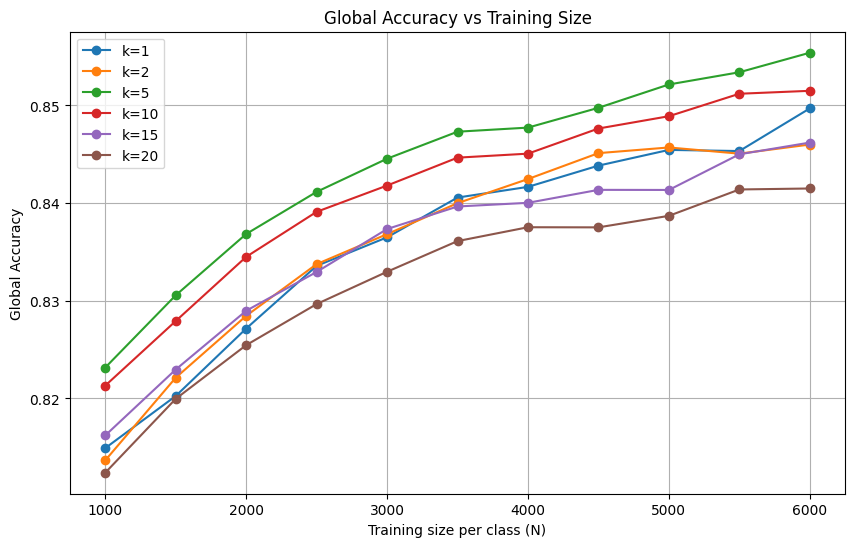

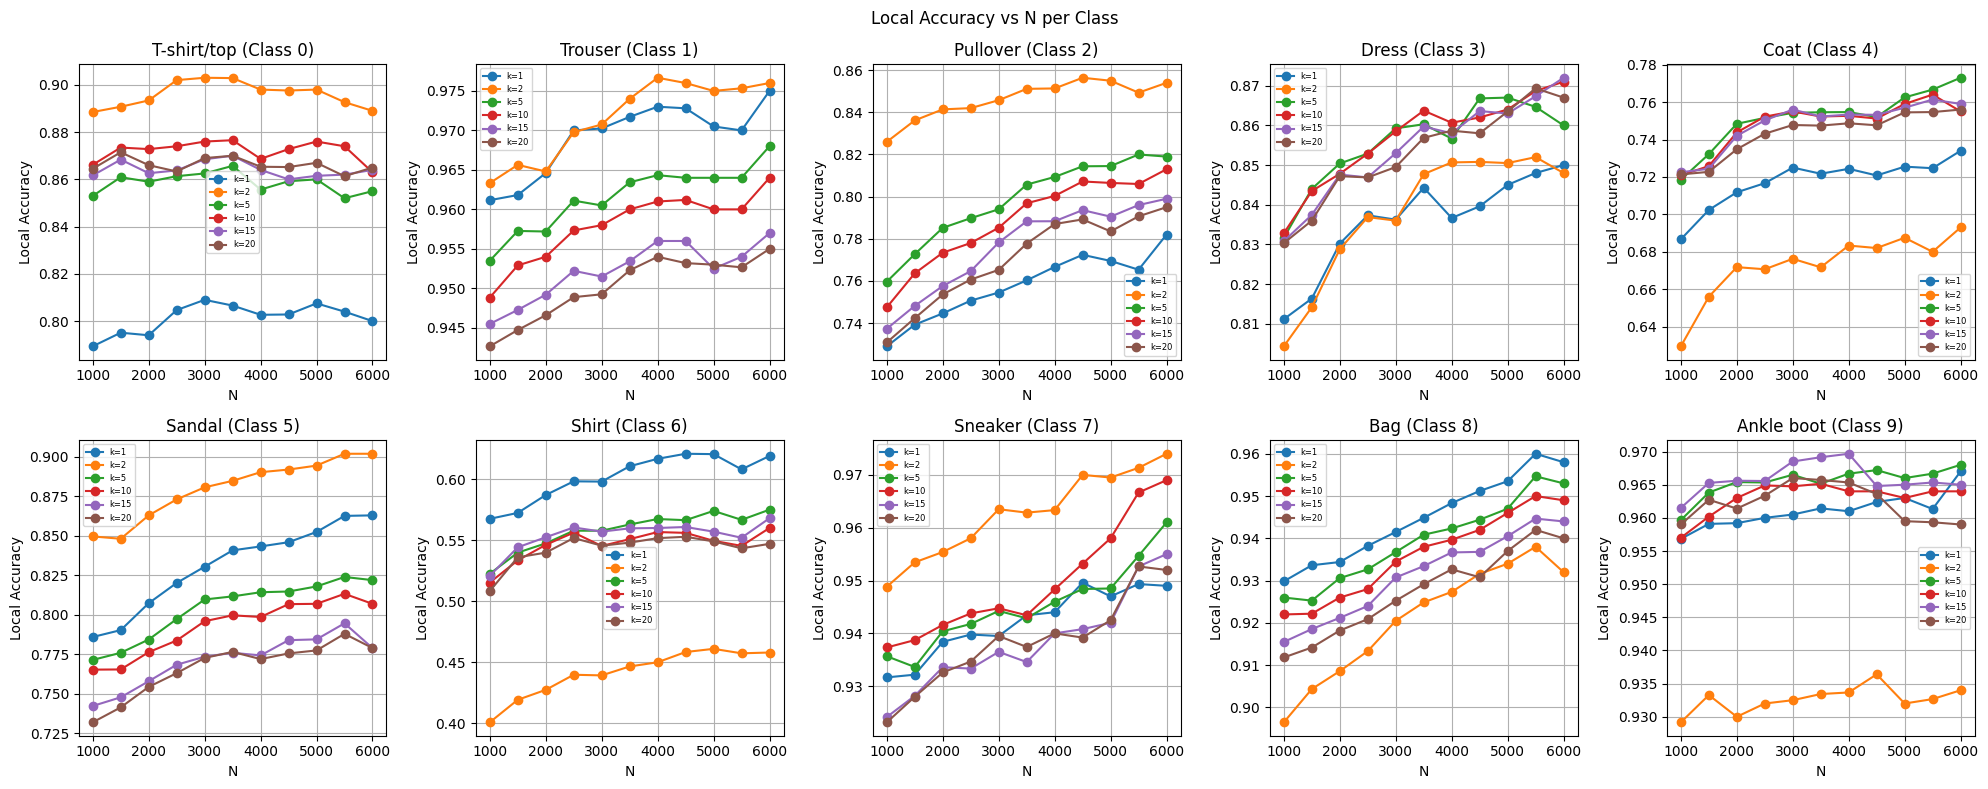

In [54]:
analyze_knn_results(df_q2)

In [55]:
# Best k per N: random vs sequential sampling
best_q1 = df_q1.loc[df_q1.groupby('N')['global_accuracy'].idxmax(), ['N', 'k', 'global_accuracy']]
best_q2 = df_q2.loc[df_q2.groupby('N')['global_accuracy'].idxmax(), ['N', 'k', 'global_accuracy']]
best_comparison = best_q1.merge(best_q2, on='N', suffixes=('_random', '_sequential'))
print("Best k per N: random vs sequential\n")
print(best_comparison)

Best k per N: random vs sequential

       N  k_random  global_accuracy_random  k_sequential  \
0   1000         5                0.825550             5   
1   1500         5                0.831073             5   
2   2000         5                0.837120             5   
3   2500         5                0.841911             5   
4   3000         5                0.845900             5   
5   3500         5                0.845886             5   
6   4000         5                0.851200             5   
7   4500         5                0.853800             5   
8   5000         5                0.856800             5   
9   5500         5                0.852733             5   
10  6000         5                0.868000             5   

    global_accuracy_sequential  
0                     0.823167  
1                     0.830564  
2                     0.836840  
3                     0.841156  
4                     0.844550  
5                     0.847314  
6           

In [56]:
# Local per-class accuracy difference: random - sequential
local_diff = []

for k in sorted(df_q1['k'].unique()):
  r_k = df_q1[df_q1['k'] == k]
  s_k = df_q2[df_q2['k'] == k]

  for N in sorted(r_k['N'].unique()):
    r_row = r_k[r_k['N'] == N].iloc[0]
    s_row = s_k[s_k['N'] == N].iloc[0]
    diff = np.array(r_row['local_accuracy']) - np.array(s_row['local_accuracy'])
    for c in range(10):
      local_diff.append({
        'N': N,
        'k': k,
        'class': f"{class_names[c]} ({c})",
        'diff_random_minus_sequential': diff[c]
      })

df_local_diff = pd.DataFrame(local_diff)
print(df_local_diff)

# Average local accuracy difference per class across all N and k
summary_local = df_local_diff.groupby('class')['diff_random_minus_sequential'].mean()
print("\nAverage (random - sequential) local accuracy per class:\n")
print(summary_local)

        N   k            class  diff_random_minus_sequential
0    1000   1  T-shirt/top (0)                     -0.017000
1    1000   1      Trouser (1)                      0.001333
2    1000   1     Pullover (2)                     -0.009167
3    1000   1        Dress (3)                     -0.005333
4    1000   1         Coat (4)                     -0.003833
..    ...  ..              ...                           ...
655  6000  20       Sandal (5)                      0.024000
656  6000  20        Shirt (6)                      0.029000
657  6000  20      Sneaker (7)                     -0.003000
658  6000  20          Bag (8)                      0.002000
659  6000  20   Ankle boot (9)                     -0.002000

[660 rows x 4 columns]

Average (random - sequential) local accuracy per class:

class
Ankle boot (9)    -0.002627
Bag (8)            0.004693
Coat (4)           0.002426
Dress (3)          0.000854
Pullover (2)       0.001623
Sandal (5)         0.006007
Shirt (6)   

In [57]:
# Compare global accuracy: random vs sequential sampling
comparison_q2 = df_q1.merge(df_q2, on=['N','k'], suffixes=('_random','_sequential'))
comparison_q2['accuracy_difference'] = (comparison_q2['global_accuracy_random'] - comparison_q2['global_accuracy_sequential'])
print("Random vs Sequential Comparison:\n")
print(comparison_q2[['N','k','global_accuracy_random','global_accuracy_sequential','accuracy_difference']])

Random vs Sequential Comparison:

       N   k  global_accuracy_random  global_accuracy_sequential  \
0   1000   1                0.812000                    0.814917   
1   1000   2                0.813350                    0.813667   
2   1000   5                0.825550                    0.823167   
3   1000  10                0.824417                    0.821317   
4   1000  15                0.818883                    0.816217   
..   ...  ..                     ...                         ...   
61  6000   2                0.860700                    0.846000   
62  6000   5                0.868000                    0.855400   
63  6000  10                0.863200                    0.851500   
64  6000  15                0.856800                    0.846200   
65  6000  20                0.853300                    0.841500   

    accuracy_difference  
0             -0.002917  
1             -0.000317  
2              0.002383  
3              0.003100  
4              0.00

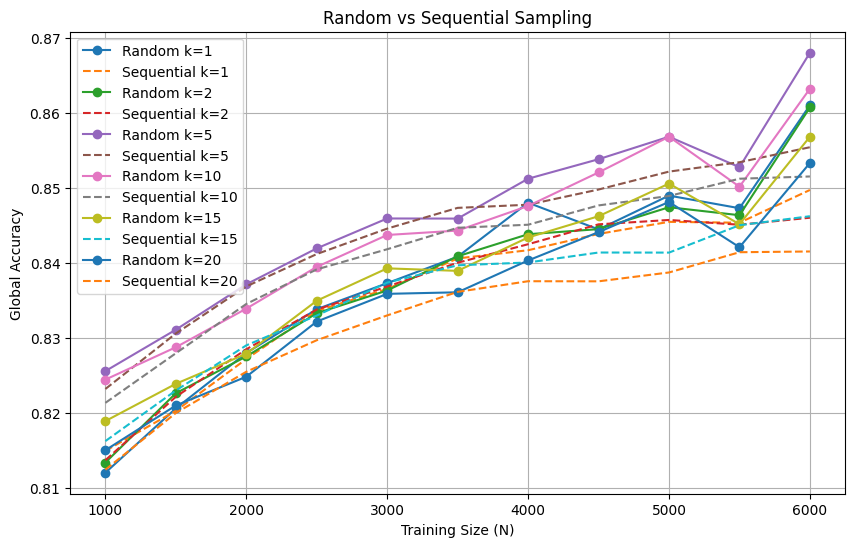

In [58]:
# Plot global accuracy comparison: random vs sequential sampling for each k
plt.figure(figsize=(10,6))

for k in df_q1['k'].unique():
  rand = df_q1[df_q1['k']==k]
  seq = df_q2[df_q2['k']==k]
  plt.plot(rand['N'], rand['global_accuracy'], marker='o', label=f'Random k={k}')
  plt.plot(seq['N'], seq['global_accuracy'], linestyle='--', label=f'Sequential k={k}')

plt.xlabel("Training Size (N)")
plt.ylabel("Global Accuracy")
plt.title("Random vs Sequential Sampling")
plt.legend()
plt.grid(True)
plt.show()

**Question 3:** Effect of Distance Metric on KNN Performance (L1 vs L2 Norm)

In [59]:
# KNN with random per-class sampling and L1 (Manhattan) distance
results_q3 = run_knn(X, y, sample_per_class_random, 'manhattan', 500)
df_q3 = pd.DataFrame(results_q3)
df_q3.to_csv("q3_results.csv", index=False)
print("\nResults saved to q3_results.csv\n")
print(df_q3)

Processing training size N=1000
Processing training size N=1500
Processing training size N=2000
Processing training size N=2500
Processing training size N=3000
Processing training size N=3500
Processing training size N=4000
Processing training size N=4500
Processing training size N=5000
Processing training size N=5500
Processing training size N=6000

Results saved to q3_results.csv

       N   k  global_accuracy  \
0   1000   1         0.821867   
1   1000   2         0.816250   
2   1000   5         0.829967   
3   1000  10         0.829800   
4   1000  15         0.823950   
..   ...  ..              ...   
61  6000   2         0.850300   
62  6000   5         0.862300   
63  6000  10         0.862400   
64  6000  15         0.858200   
65  6000  20         0.853100   

                                       local_accuracy  
0   [0.8005, 0.9593333333333334, 0.7205, 0.8206666...  
1   [0.8988333333333334, 0.9611666666666666, 0.831...  
2   [0.861, 0.9525, 0.7741666666666667, 0.8515, 0

Global Accuracy Table:

k         1       2       5       10      15      20
N                                                   
1000  0.8219  0.8162  0.8300  0.8298  0.8240  0.8202
1500  0.8294  0.8243  0.8394  0.8366  0.8327  0.8291
2000  0.8351  0.8307  0.8444  0.8403  0.8370  0.8343
2500  0.8370  0.8331  0.8473  0.8442  0.8416  0.8388
3000  0.8415  0.8400  0.8489  0.8470  0.8424  0.8392
3500  0.8475  0.8409  0.8558  0.8523  0.8480  0.8443
4000  0.8484  0.8444  0.8545  0.8534  0.8502  0.8471
4500  0.8528  0.8488  0.8624  0.8609  0.8561  0.8540
5000  0.8539  0.8516  0.8632  0.8604  0.8553  0.8522
5500  0.8555  0.8531  0.8647  0.8601  0.8552  0.8521
6000  0.8595  0.8503  0.8623  0.8624  0.8582  0.8531

Best k per N:

       N   k  global_accuracy
2   1000   5         0.829967
8   1500   5         0.839400
14  2000   5         0.844440
20  2500   5         0.847333
26  3000   5         0.848875
32  3500   5         0.855771
38  4000   5         0.854533
44  4500   5         0.862400
5

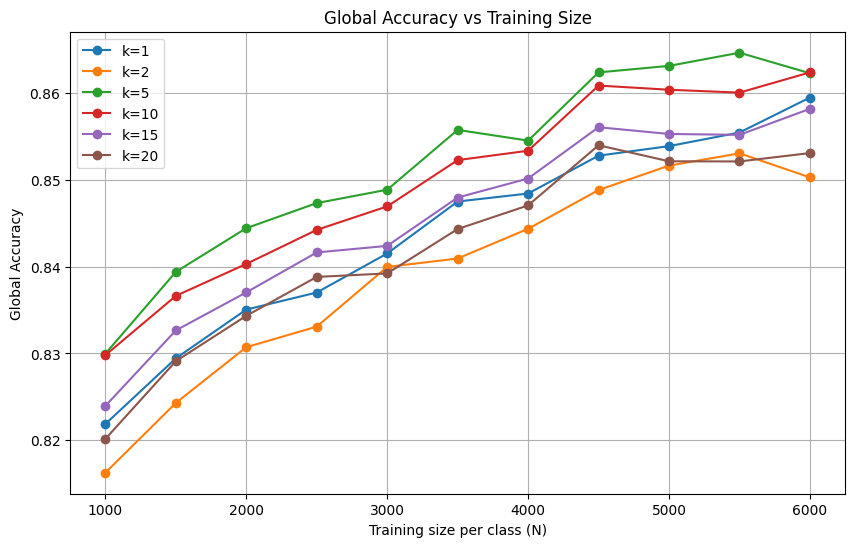

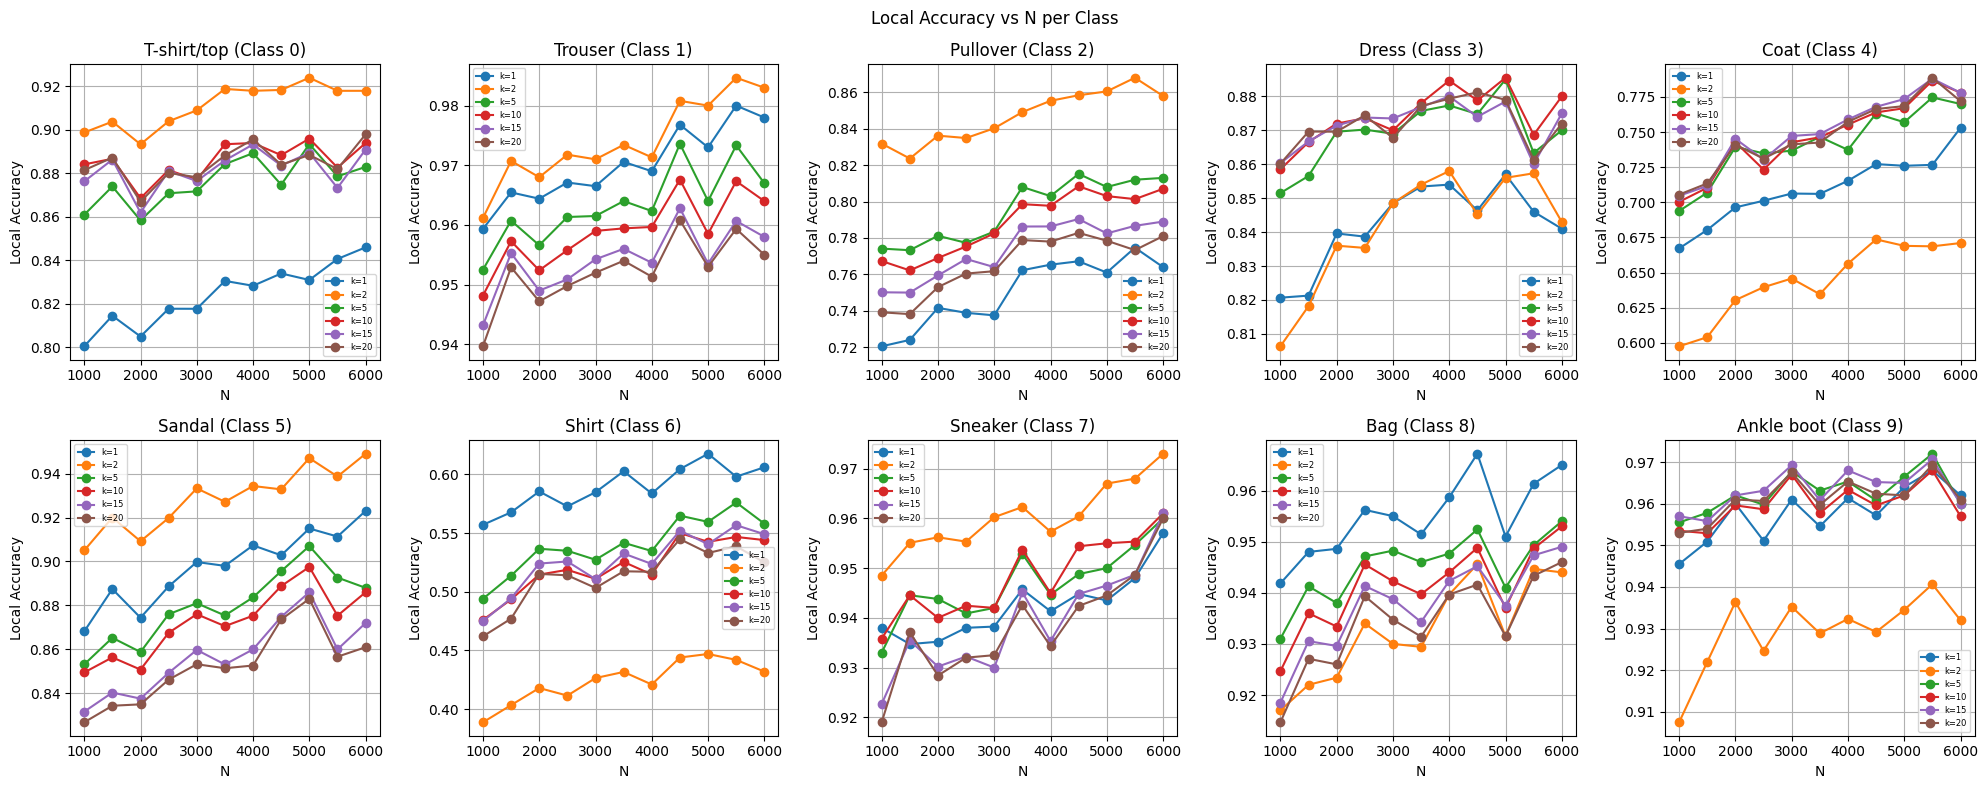

In [60]:
analyze_knn_results(df_q3)

In [61]:
# Compare global accuracy: L2 (Euclidean) vs L1 (Manhattan) for each (N, k)
comparison_q3 = df_q1.merge(df_q3, on=['N','k'], suffixes=('_L2','_L1'))
comparison_q3['accuracy_difference'] = (comparison_q3['global_accuracy_L2'] - comparison_q3['global_accuracy_L1'])
print("L2 (euclidean) vs L1 (manhattan) Comparison:\n")
print(comparison_q3[['N','k','global_accuracy_L2','global_accuracy_L1','accuracy_difference']])

L2 (euclidean) vs L1 (manhattan) Comparison:

       N   k  global_accuracy_L2  global_accuracy_L1  accuracy_difference
0   1000   1            0.812000            0.821867            -0.009867
1   1000   2            0.813350            0.816250            -0.002900
2   1000   5            0.825550            0.829967            -0.004417
3   1000  10            0.824417            0.829800            -0.005383
4   1000  15            0.818883            0.823950            -0.005067
..   ...  ..                 ...                 ...                  ...
61  6000   2            0.860700            0.850300             0.010400
62  6000   5            0.868000            0.862300             0.005700
63  6000  10            0.863200            0.862400             0.000800
64  6000  15            0.856800            0.858200            -0.001400
65  6000  20            0.853300            0.853100             0.000200

[66 rows x 5 columns]


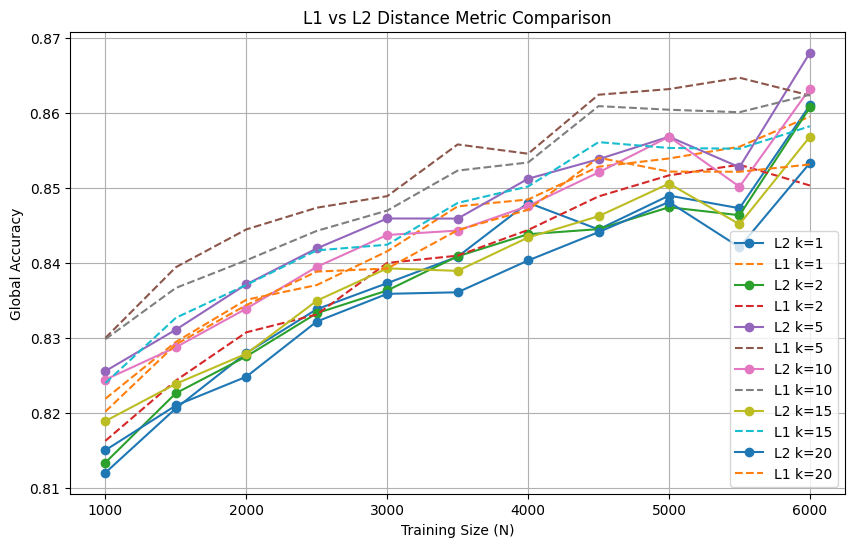

In [62]:
# Plot global accuracy vs N comparing L1 vs L2 for each k
plt.figure(figsize=(10,6))

for k in df_q1['k'].unique():
  l2 = df_q1[df_q1['k']==k]
  l1 = df_q3[df_q3['k']==k]
  plt.plot(l2['N'], l2['global_accuracy'], marker='o', label=f'L2 k={k}')
  plt.plot(l1['N'], l1['global_accuracy'], linestyle='--', label=f'L1 k={k}')

plt.xlabel("Training Size (N)")
plt.ylabel("Global Accuracy")
plt.title("L1 vs L2 Distance Metric Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
# Local per-class accuracy difference: L2 - L1 (for each N, k, class)
local_diff_l1l2 = []

for k in sorted(df_q1['k'].unique()):
  l2_k = df_q1[df_q1['k'] == k]
  l1_k = df_q3[df_q3['k'] == k]

  for N in sorted(l2_k['N'].unique()):
    l2_row = l2_k[l2_k['N'] == N].iloc[0]
    l1_row = l1_k[l1_k['N'] == N].iloc[0]
    diff = np.array(l2_row['local_accuracy']) - np.array(l1_row['local_accuracy'])
    for c in range(10):
      local_diff_l1l2.append({
        'N': N,
        'k': k,
        'class': f"{class_names[c]} ({c})",
        'diff_L2_minus_L1': diff[c]
      })

df_local_diff_l1l2 = pd.DataFrame(local_diff_l1l2)
print(df_local_diff_l1l2)

# Average local accuracy difference per class (L2 - L1) across all N and k
summary_local_l1l2 = df_local_diff_l1l2.groupby('class')['diff_L2_minus_L1'].agg(['mean', 'std'])
summary_local_l1l2.columns = ['mean_diff', 'std_diff']
print("\nAverage (L2 - L1) local accuracy per class (across all N, k):\n")
print(summary_local_l1l2)

        N   k            class  diff_L2_minus_L1
0    1000   1  T-shirt/top (0)         -0.028167
1    1000   1      Trouser (1)          0.003167
2    1000   1     Pullover (2)         -0.000667
3    1000   1        Dress (3)         -0.014833
4    1000   1         Coat (4)          0.015667
..    ...  ..              ...               ...
655  6000  20       Sandal (5)         -0.058000
656  6000  20        Shirt (6)          0.051000
657  6000  20      Sneaker (7)         -0.011000
658  6000  20          Bag (8)         -0.004000
659  6000  20   Ankle boot (9)         -0.004000

[660 rows x 4 columns]

Average (L2 - L1) local accuracy per class (across all N, k):

                 mean_diff  std_diff
class                               
Ankle boot (9)    0.000006  0.004303
Bag (8)          -0.002897  0.006079
Coat (4)          0.009242  0.015004
Dress (3)        -0.012006  0.011153
Pullover (2)      0.004501  0.014175
Sandal (5)       -0.067623  0.016899
Shirt (6)         0.023771  